In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.simulation.synthetic_worlds.fair_world import simulate_fair_world
from src.simulation.preprocessing import preprocess

# Models
from src.simulation.train_lr_sim import train_logistic_regression
from src.simulation.train_mlp_sim import train_mlp_model, MLP
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler




SEED = 42


In [7]:
df = simulate_fair_world(n_samples=10000, seed=SEED)

df.head()


,race,gender,age,glucose_measured,hba1c_measured,diabetes_label
0,0,0,66.807657,86.260274,5.264139,0
1,2,1,49.977538,94.787618,4.977199,0
2,1,1,41.819978,88.619829,5.321474,0
3,0,1,51.230187,103.810522,5.338681,0
4,0,0,44.494660,165.847420,7.429512,1


In [29]:
X = df[["age", "glucose_measured", "hba1c_measured"]]
y = df["diabetes_label"]
A = df[["race", "gender"]]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=SEED,
    stratify=y
)

# align sensitive attributes by index
A_train = A.loc[X_train.index]
A_test  = A.loc[X_test.index]




Train size: 7000
Test size: 3000
Train diabetes prevalence: 0.1967142857142857
Test diabetes prevalence: 0.19666666666666666


In [32]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print("Train size:", len(X_train_s))
print("Test size:", len(X_test_s))
print("Train diabetes prevalence:", y_train.mean())
print("Test diabetes prevalence:", y_test.mean())

Train size: 7000
Test size: 3000
Train diabetes prevalence: 0.1967142857142857
Test diabetes prevalence: 0.19666666666666666


In [33]:
lr_results = train_logistic_regression(
    X_train_s, y_train,
    X_test_s, y_test
)

print("LR Accuracy:", lr_results["accuracy"])


LR Accuracy: 0.9986666666666667


In [34]:
# Logistic Regression outputs
lr_pred  = lr_results["y_pred"]
lr_proba = lr_results["y_proba"]

In [35]:
nn_results = train_mlp_model(
    X_train_s, y_train,
    X_test_s, y_test,
    input_dim=X_train_s.shape[1]
)

print("NN Accuracy:", nn_results["accuracy"])

NN Accuracy: 0.9583333333333334


In [36]:


# Neural Network outputs
nn_pred  = nn_results["y_pred"]
nn_proba = nn_results["y_proba"]


In [37]:
def compute_group_rates(y_true, y_pred, group, group_name="group"):
    """
    Returns a DataFrame with TPR, FNR, FPR, TNR per group.
    """
    rows = []

    for g in sorted(np.unique(group)):
        idx = group == g

        tp = ((y_pred[idx] == 1) & (y_true[idx] == 1)).sum()
        fn = ((y_pred[idx] == 0) & (y_true[idx] == 1)).sum()
        fp = ((y_pred[idx] == 1) & (y_true[idx] == 0)).sum()
        tn = ((y_pred[idx] == 0) & (y_true[idx] == 0)).sum()

        tpr = tp / (tp + fn + 1e-9)  # sensitivity
        fnr = fn / (tp + fn + 1e-9)  # miss rate
        fpr = fp / (fp + tn + 1e-9)  # false alarm
        tnr = tn / (fp + tn + 1e-9)  # specificity

        rows.append({
            group_name: g,
            "TPR": tpr,
            "FNR": fnr,
            "FPR": fpr,
            "TNR": tnr
        })

    return pd.DataFrame(rows)

In [38]:
def compute_rate_gaps(rate_df):
    """
    Takes output of compute_group_rates
    and returns max–min gaps for each rate.
    """
    gaps = {}
    for col in ["TPR", "FNR", "FPR", "TNR"]:
        gaps[col] = rate_df[col].max() - rate_df[col].min()
    return gaps


In [51]:
lr_rates_gender = compute_group_rates(
    y_test.values,
    lr_pred,
    A_test["gender"].values,
    group_name="gender"
)

lr_gaps_gender = compute_rate_gaps(lr_rates_gender)

print("LR – Gender rates")
print(lr_rates_gender)
print("LR – Gender gaps:", lr_gaps_gender)


nn_rates_gender = compute_group_rates(
    y_test.values,
    nn_pred,
    A_test["gender"].values,
    group_name="gender"
)

nn_gaps_gender = compute_rate_gaps(nn_rates_gender)

print("NN – Gender rates")
print(nn_rates_gender)
print("NN – Gender gaps:", nn_gaps_gender)


LR – Gender rates
   gender       TPR       FNR  FPR  TNR
0       0  0.989726  0.010274  0.0  1.0
1       1  0.996644  0.003356  0.0  1.0
LR – Gender gaps: {'TPR': np.float64(0.006918267904798214), 'FNR': np.float64(0.006918267904729225), 'FPR': np.float64(0.0), 'TNR': np.float64(3.863576125695545e-14)}
NN – Gender rates
   gender       TPR       FNR  FPR  TNR
0       0  0.767123  0.232877  0.0  1.0
1       1  0.808725  0.191275  0.0  1.0
NN – Gender gaps: {'TPR': np.float64(0.041601544543445446), 'FNR': np.float64(0.041601544543376556), 'FPR': np.float64(0.0), 'TNR': np.float64(3.863576125695545e-14)}


In [52]:
lr_rates_race = compute_group_rates(
    y_test.values,
    lr_pred,
    A_test["race"].values,
    group_name="race"
)

lr_gaps_race = compute_rate_gaps(lr_rates_race)

print("LR – Race rates")
print(lr_rates_race)
print("LR – Race gaps:", lr_gaps_race)


nn_rates_race = compute_group_rates(
    y_test.values,
    nn_pred,
    A_test["race"].values,
    group_name="race"
)

nn_gaps_race = compute_rate_gaps(nn_rates_race)

print("NN – Race rates")
print(nn_rates_race)
print("NN – Race gaps:", nn_gaps_race)


LR – Race rates
   race       TPR       FNR  FPR  TNR
0     0  0.991736  0.008264  0.0  1.0
1     1  0.992958  0.007042  0.0  1.0
2     2  1.000000  0.000000  0.0  1.0
LR – Race gaps: {'TPR': np.float64(0.008264462800884664), 'FNR': np.float64(0.008264462809894589), 'FPR': np.float64(0.0), 'TNR': np.float64(2.264965992537782e-12)}
NN – Race rates
   race       TPR       FNR  FPR  TNR
0     0  0.776860  0.223140  0.0  1.0
1     1  0.774648  0.225352  0.0  1.0
2     2  0.858824  0.141176  0.0  1.0
NN – Race gaps: {'TPR': np.float64(0.08417564208317241), 'FNR': np.float64(0.08417564208789496), 'FPR': np.float64(0.0), 'TNR': np.float64(2.264965992537782e-12)}


In [43]:
print("LR accuracy:", lr_results["accuracy"])
print("NN accuracy:", nn_results["accuracy"])


LR accuracy: 0.9986666666666667
NN accuracy: 0.9583333333333334


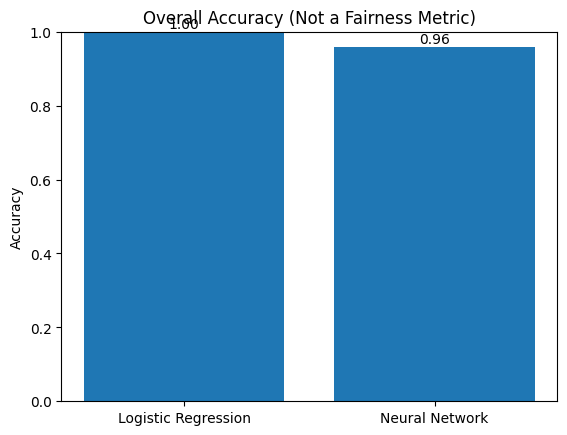

In [46]:


models = ["Logistic Regression", "Neural Network"]
accs = [lr_results["accuracy"], nn_results["accuracy"]]

plt.bar(models, accs)
plt.ylabel("Accuracy")
plt.title("Overall Accuracy (Not a Fairness Metric)")
plt.ylim(0, 1)
for i, v in enumerate(accs):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")
plt.show()


In [47]:


def plot_lr_nn_rates(lr_rates, nn_rates, group_col, title):
    """
    lr_rates, nn_rates: DataFrames from compute_group_rates
    group_col: "race" or "gender"
    """

    metrics = ["TPR", "FNR", "FPR", "TNR"]
    groups = lr_rates[group_col].values

    x = np.arange(len(groups))
    width = 0.35

    fig, axes = plt.subplots(1, len(metrics), figsize=(18, 4), sharey=False)
    fig.suptitle(title, fontsize=14)

    for i, metric in enumerate(metrics):
        ax = axes[i]


        lr_vals = lr_rates[metric].values
        nn_vals = nn_rates[metric].values

        bars_lr = ax.bar(x - width/2, lr_vals, width, label="LR")
        bars_nn = ax.bar(x + width/2, nn_vals, width, label="NN")

        ax.set_title(metric)
        ax.set_xticks(x)
        ax.set_xticklabels(groups)
        ax.set_ylim(0, 1)

        # annotate bars
        for bar in bars_lr:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f"{h:.2f}", ha="center", va="bottom", fontsize=9)

        for bar in bars_nn:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f"{h:.2f}", ha="center", va="bottom", fontsize=9)

        if i == 0:
            ax.legend()

    plt.tight_layout()
    plt.show()


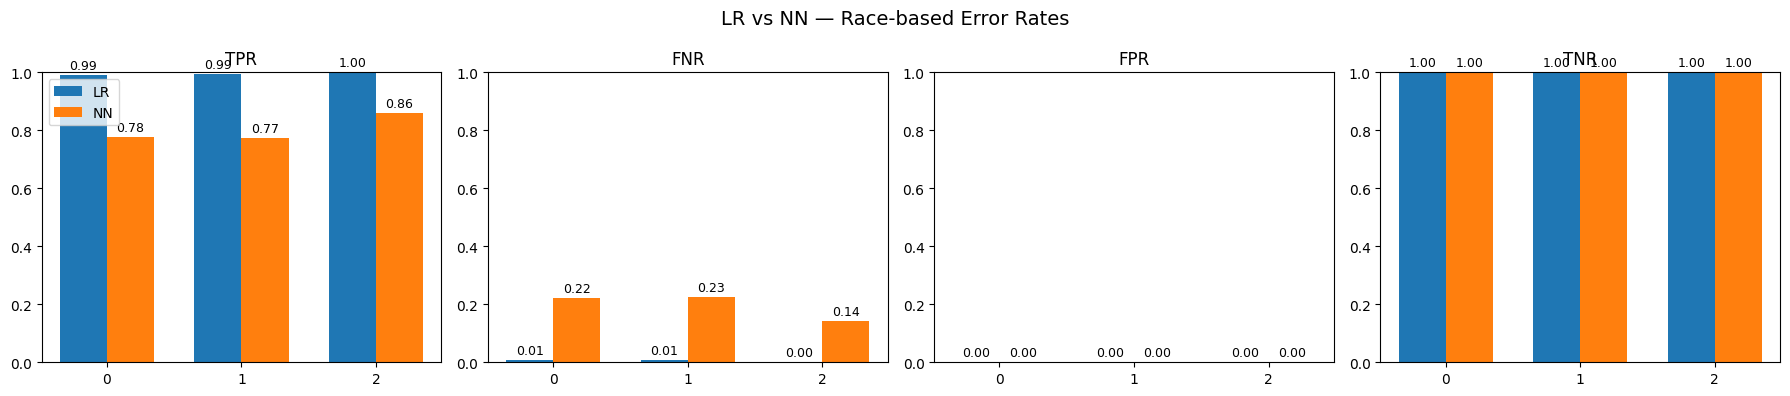

In [48]:
plot_lr_nn_rates(
    lr_rates_race,
    nn_rates_race,
    group_col="race",
    title="LR vs NN — Race-based Error Rates"
)


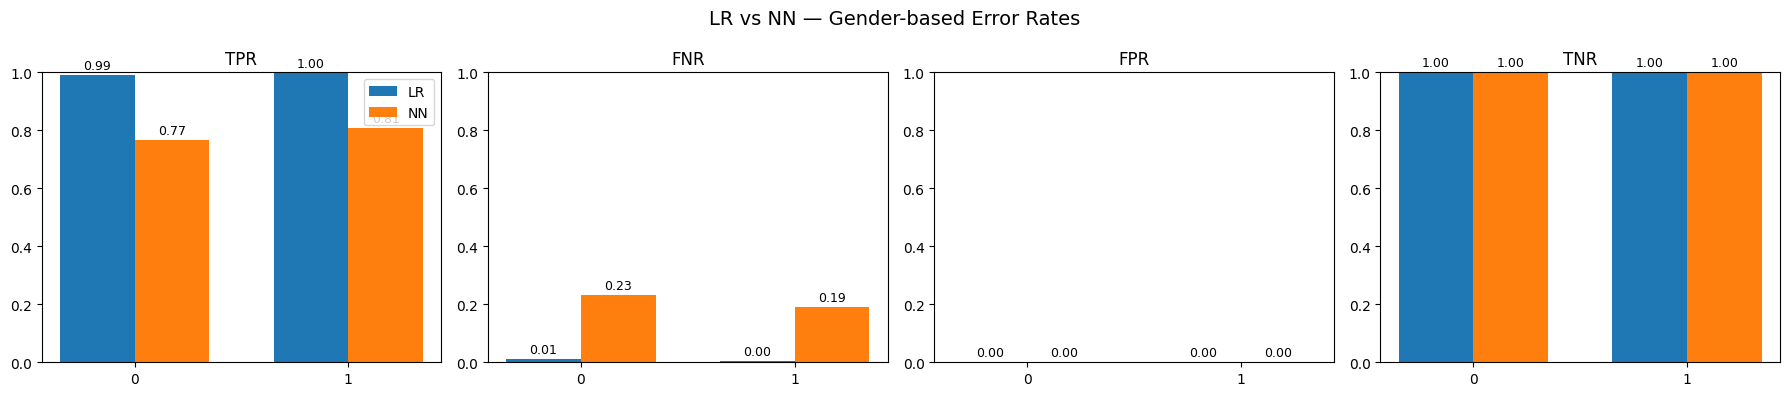

In [49]:
plot_lr_nn_rates(
    lr_rates_gender,
    nn_rates_gender,
    group_col="gender",
    title="LR vs NN — Gender-based Error Rates"
)
